# XGBoost — Recording-Level Pipeline

This notebook fixes the frame-level training problem in `Coding Pipeline.ipynb`.
BPM is a constant label per recording, so training on individual frames produces
universally negative R². Here we:

1. Load pre-normalisation frame features (`stage_3_window_stats_filled.parquet`)
2. Aggregate frames → per-recording mean + std statistics
3. MinMax-normalise per speaker (bilingual speakers treated as one unit)
4. Speaker-independent 70/15/15 split stratified by language × gender
5. Coarse → fine XGBoost hyperparameter search with speaker-independent CV
6. Evaluate best model on the held-out validation set

In [11]:
# =============================================================================
# Cell 1 — Imports & configuration
# =============================================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import (
    RandomizedSearchCV, GridSearchCV, StratifiedGroupKFold, train_test_split
)
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor

# --- Paths -------------------------------------------------------------------
BASE_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local")
DATA_PATH = BASE_DIR / "data" / "stage_3_window_stats_filled.parquet"
META_PATH = BASE_DIR / "data" / "tesdhe_metadata.csv"
OUT_DIR   = BASE_DIR / "outputs" / "recording_level"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Reproducibility ---------------------------------------------------------
RANDOM_STATE = 42
TRAIN_SIZE   = 0.70
VAL_SIZE     = 0.15
TEST_SIZE    = 0.15

# --- CV / search config ------------------------------------------------------
N_FOLDS = 5
N_ITER  = 40

# Columns that are identifiers or target — not features
NON_FEATURE_COLS = {"file_name", "frame_idx", "bpm"}

pd.set_option("display.float_format", "{:.4f}".format)
print("Config loaded.")

Config loaded.


In [12]:
# =============================================================================
# Cell 2 — Load frame-level data & attach metadata
# =============================================================================
frames = pd.read_parquet(DATA_PATH)
meta   = pd.read_csv(META_PATH)

print(f"Frames shape : {frames.shape}")
print(f"Metadata shape: {meta.shape}")

# Attach speaker_id, language, gender, age_years from metadata
meta_cols = meta[["file_name", "speaker_id", "language", "gender", "age_years"]].drop_duplicates("file_name")
frames = frames.merge(meta_cols, on="file_name", how="left")

n_null = frames["speaker_id"].isna().sum()
assert n_null == 0, f"{n_null} frames have no speaker_id after merge"

print(f"\nAfter metadata merge: {frames.shape}")
print(f"Unique recordings : {frames['file_name'].nunique()}")
print(f"Unique speakers   : {frames['speaker_id'].nunique()}")
print(f"BPM range         : {frames['bpm'].min()} – {frames['bpm'].max()}")

Frames shape : (1252312, 95)
Metadata shape: (10034, 13)

After metadata merge: (1252312, 99)
Unique recordings : 10034
Unique speakers   : 109
BPM range         : 48 – 178


In [13]:
# =============================================================================
# Cell 3 — Aggregate frames → recording-level mean + std statistics
# =============================================================================
FEATURE_COLS = [c for c in frames.columns if c not in NON_FEATURE_COLS
                and c not in {"speaker_id", "language", "gender", "age_years"}]

print(f"Frame-level feature columns: {len(FEATURE_COLS)}")

# Mean and std of every feature, grouped per recording
agg = frames.groupby("file_name")[FEATURE_COLS].agg(["mean", "std"])
agg.columns = ["_".join(c) for c in agg.columns]  # e.g. mfcc_1_mean, mfcc_1_std
agg = agg.reset_index()

# Recording-level target and metadata
rec_meta = (
    frames.groupby("file_name")
          .agg(bpm=("bpm", "first"),
               speaker_id=("speaker_id", "first"),
               language=("language", "first"),
               gender=("gender", "first"),
               age_years=("age_years", "first"))
          .reset_index()
)

rec_df = rec_meta.merge(agg, on="file_name", how="left")

REC_FEATURE_COLS = [c for c in rec_df.columns
                    if c not in {"file_name", "bpm", "speaker_id",
                                 "language", "gender", "age_years"}]

print(f"\nRecording-level dataframe : {rec_df.shape}")
print(f"Recording-level features  : {len(REC_FEATURE_COLS)}")
print(f"NaN in features           : {rec_df[REC_FEATURE_COLS].isna().sum().sum()}")
print(f"\nSample rows:")
rec_df[["file_name", "bpm", "speaker_id", "language", "gender"]].head()

Frame-level feature columns: 92

Recording-level dataframe : (10034, 190)
Recording-level features  : 184
NaN in features           : 0

Sample rows:


,file_name,bpm,speaker_id,language,gender
0,En001M240401A083.ogg,83,1,English,M
1,En001M240402A079.ogg,79,1,English,M
2,En001M240403A076.ogg,76,1,English,M
3,En001M240404A076.ogg,76,1,English,M
4,En001M240405A071.ogg,71,1,English,M


In [14]:
# =============================================================================
# Cell 4 — Per-speaker MinMax normalisation
# =============================================================================
rec_df = rec_df.reset_index(drop=True)

# Upcast to float64 so MinMaxScaler output can be written back without a
# pandas dtype-upcast error (stage_3 stores features as float32).
rec_df[REC_FEATURE_COLS] = rec_df[REC_FEATURE_COLS].astype(np.float64)

# Replace inf/-inf and fill NaN with 0 before normalisation.
n_inf = np.isinf(rec_df[REC_FEATURE_COLS].values).sum()
rec_df[REC_FEATURE_COLS] = rec_df[REC_FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
n_nan = rec_df[REC_FEATURE_COLS].isna().sum().sum()
rec_df[REC_FEATURE_COLS] = rec_df[REC_FEATURE_COLS].fillna(0.0)
print(f"Replaced {n_inf} inf and {n_nan} NaN values with 0.")

# --- Per-speaker normalisation -----------------------------------------------
single_rec_speakers = []

for spk_id, grp in rec_df.groupby("speaker_id"):
    idx = grp.index.tolist()
    if len(idx) == 1:
        single_rec_speakers.append(spk_id)
    data = rec_df.loc[idx, REC_FEATURE_COLS].values
    scaler = MinMaxScaler()
    rec_df.loc[idx, REC_FEATURE_COLS] = scaler.fit_transform(data)

# Clip to [0, 1] to eliminate any floating-point precision overshoot
# (IEEE 754 arithmetic can produce values like 1.0000000000000002).
rec_df[REC_FEATURE_COLS] = rec_df[REC_FEATURE_COLS].clip(0.0, 1.0)

print(f"Speakers with only 1 recording (mapped to 0.0): {len(single_rec_speakers)}")

# Sanity: all finite feature values must be in [0, 1]
vals = rec_df[REC_FEATURE_COLS].values
finite_vals = vals[np.isfinite(vals)]
feature_min = finite_vals.min()
feature_max = finite_vals.max()
print(f"\nFeature range after per-speaker normalisation: [{feature_min:.6f}, {feature_max:.6f}]")
assert feature_min >= 0.0 and feature_max <= 1.0, "Normalisation out of [0,1] range"
print("Normalisation check passed.")

Replaced 0 inf and 0 NaN values with 0.
Speakers with only 1 recording (mapped to 0.0): 0

Feature range after per-speaker normalisation: [0.000000, 1.000000]
Normalisation check passed.


In [15]:
# =============================================================================
# Cell 5 — Speaker-independent 70 / 15 / 15 split
#
# Split is performed at the speaker level (all recordings from one speaker
# go to the same partition). Bilingual speakers are assigned a single stratum
# using their first-occurring language (consistent with Coding Pipeline.ipynb).
# =============================================================================
speakers = (
    rec_df.groupby("speaker_id")
          .agg(language=("language", "first"),
               gender=("gender", "first"))
          .reset_index()
)
speakers["stratum"] = speakers["language"] + "_" + speakers["gender"]

train_spk, temp_spk = train_test_split(
    speakers,
    test_size=(VAL_SIZE + TEST_SIZE),
    stratify=speakers["stratum"],
    random_state=RANDOM_STATE,
)
val_spk, test_spk = train_test_split(
    temp_spk,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    stratify=temp_spk["stratum"],
    random_state=RANDOM_STATE,
)

# Propagate stratum back to rec_df
rec_df = rec_df.merge(speakers[["speaker_id", "stratum"]], on="speaker_id", how="left")

train_mask = rec_df["speaker_id"].isin(train_spk["speaker_id"])
val_mask   = rec_df["speaker_id"].isin(val_spk["speaker_id"])
test_mask  = rec_df["speaker_id"].isin(test_spk["speaker_id"])

GROUP_COLS = ["speaker_id", "file_name", "language", "gender", "stratum"]

X_train = rec_df.loc[train_mask, REC_FEATURE_COLS].reset_index(drop=True)
y_train = rec_df.loc[train_mask, "bpm"].reset_index(drop=True)
groups_train = rec_df.loc[train_mask, GROUP_COLS].reset_index(drop=True)

X_val = rec_df.loc[val_mask, REC_FEATURE_COLS].reset_index(drop=True)
y_val = rec_df.loc[val_mask, "bpm"].reset_index(drop=True)
groups_val = rec_df.loc[val_mask, GROUP_COLS].reset_index(drop=True)

X_test = rec_df.loc[test_mask, REC_FEATURE_COLS].reset_index(drop=True)
y_test = rec_df.loc[test_mask, "bpm"].reset_index(drop=True)
groups_test = rec_df.loc[test_mask, GROUP_COLS].reset_index(drop=True)

# --- Sanity report -----------------------------------------------------------
assert len(set(train_spk["speaker_id"]) & set(val_spk["speaker_id"])) == 0
assert len(set(train_spk["speaker_id"]) & set(test_spk["speaker_id"])) == 0
assert len(set(val_spk["speaker_id"]) & set(test_spk["speaker_id"])) == 0

print(f"Speakers  → train: {len(train_spk)}  val: {len(val_spk)}  test: {len(test_spk)}")
print(f"Recordings→ train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")
for col in ["language", "gender"]:
    comp = pd.concat([
        train_spk[col].value_counts().rename("train"),
        val_spk[col].value_counts().rename("val"),
        test_spk[col].value_counts().rename("test"),
    ], axis=1).fillna(0).astype(int)
    print(f"\nSpeakers per {col}:\n{comp}")

Speakers  → train: 76  val: 16  test: 17
Recordings→ train: 7133  val: 1331  test: 1570

Speakers per language:
          train  val  test
language                  
English      56   12    12
Tamil        20    4     5

Speakers per gender:
        train  val  test
gender                  
M          40    8     9
F          36    8     8


In [16]:
# =============================================================================
# Cell 6 — Speaker-independent stratified CV fold setup
#
# StratifiedGroupKFold ensures:
#   - No speaker appears in both train and validation within any fold
#   - Language × gender strata are balanced across folds
# At recording level, sklearn's neg_root_mean_squared_error is already
# recording-level RMSE — no custom scorer needed.
# =============================================================================
sgkf = StratifiedGroupKFold(
    n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE
)
cv_splits = list(
    sgkf.split(
        X_train,
        y=groups_train["stratum"].values,
        groups=groups_train["speaker_id"].values,
    )
)

print("=== CV fold sanity check ===")
for i, (tr_idx, va_idx) in enumerate(cv_splits, 1):
    tr_spk = set(groups_train.iloc[tr_idx]["speaker_id"])
    va_spk = set(groups_train.iloc[va_idx]["speaker_id"])
    val_strata = groups_train.iloc[va_idx]["stratum"].value_counts().to_dict()
    print(
        f"Fold {i}: train spk={len(tr_spk)}  val spk={len(va_spk)}  "
        f"overlap={len(tr_spk & va_spk)}  val rec={len(va_idx)}  "
        f"strata={val_strata}"
    )

=== CV fold sanity check ===
Fold 1: train spk=61  val spk=15  overlap=0  val rec=1446  strata={'English_M': 727, 'English_F': 438, 'Tamil_F': 186, 'Tamil_M': 95}
Fold 2: train spk=61  val spk=15  overlap=0  val rec=1366  strata={'English_M': 730, 'English_F': 441, 'Tamil_F': 128, 'Tamil_M': 67}
Fold 3: train spk=60  val spk=16  overlap=0  val rec=1484  strata={'English_M': 726, 'English_F': 441, 'Tamil_F': 186, 'Tamil_M': 131}
Fold 4: train spk=62  val spk=14  overlap=0  val rec=1361  strata={'English_M': 786, 'English_F': 381, 'Tamil_F': 127, 'Tamil_M': 67}
Fold 5: train spk=60  val spk=16  overlap=0  val rec=1476  strata={'English_M': 783, 'English_F': 440, 'Tamil_F': 186, 'Tamil_M': 67}


In [17]:
# =============================================================================
# Cell 7 — Coarse RandomizedSearchCV
# =============================================================================
coarse_distributions = {
    "n_estimators":     [200, 400, 600, 800, 1000],
    "max_depth":        [3, 5, 7, 9, 11],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1, 5, 10],
}

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=coarse_distributions,
    n_iter=N_ITER,
    scoring="neg_root_mean_squared_error",
    cv=cv_splits,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=False,
)
random_search.fit(X_train, y_train)

best_coarse = random_search.best_params_
print(f"\nBest coarse RMSE (CV): {-random_search.best_score_:.3f}")
print(f"Best coarse params  : {best_coarse}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/Thesis.env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best coarse RMSE (CV): 17.729
Best coarse params  : {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 11, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [18]:
# =============================================================================
# Cell 8 — Fine GridSearchCV around the coarse winner
# =============================================================================
def neighbours(value, candidates):
    """Return up to 4 adjacent values from candidates centred on value."""
    candidates = sorted(set(candidates))
    idx = candidates.index(value)
    return candidates[max(0, idx - 2) : min(len(candidates), idx + 2)]

fine_grid = {
    "n_estimators":     neighbours(best_coarse["n_estimators"],
                                   coarse_distributions["n_estimators"]),
    "max_depth":        neighbours(best_coarse["max_depth"],
                                   coarse_distributions["max_depth"]),
    "learning_rate":    neighbours(best_coarse["learning_rate"],
                                   coarse_distributions["learning_rate"]),
    "subsample":        [best_coarse["subsample"]],
    "colsample_bytree": [best_coarse["colsample_bytree"]],
    "min_child_weight": [best_coarse["min_child_weight"]],
    "reg_alpha":        [best_coarse["reg_alpha"]],
    "reg_lambda":       [best_coarse["reg_lambda"]],
}
print("Fine grid:", {k: v for k, v in fine_grid.items() if len(v) > 1})

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=fine_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_splits,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
grid_search.fit(X_train, y_train)

best_model  = grid_search.best_estimator_
best_params = grid_search.best_params_
print(f"\nBest fine RMSE (CV): {-grid_search.best_score_:.3f}")
print(f"Best fine params   : {best_params}")

Fine grid: {'n_estimators': [200, 400], 'max_depth': [7, 9, 11], 'learning_rate': [0.01, 0.03]}
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best fine RMSE (CV): 17.729
Best fine params   : {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 11, 'min_child_weight': 3, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.6}


In [19]:
# =============================================================================
# Cell 9 — Evaluate on held-out validation set
# =============================================================================
def metrics_block(y_true, y_pred, label=""):
    n    = len(y_true)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred)) if n > 1 else float("nan")
    tag  = f"[{label}] " if label else ""
    print(f"{tag}n={n:4d}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}")
    return {"n": n, "RMSE": rmse, "MAE": mae, "R2": r2}

# XGBoost predictions
y_val_pred = best_model.predict(X_val)

# Apples-to-apples baseline: mean of training set
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
y_val_baseline = baseline.predict(X_val)

print("=== Validation set (recording level) ===")
val_metrics = {"overall": {}}

print("\n--- Overall ---")
print("Baseline :", end=" "); metrics_block(y_val, y_val_baseline)
val_metrics["overall"] = metrics_block(y_val, y_val_pred, "XGBoost")

for col in ["gender", "language"]:
    print(f"\n--- By {col} ---")
    val_metrics[col] = {}
    for level, grp_idx in groups_val.groupby(col).groups.items():
        yt = y_val.iloc[grp_idx]
        yp = y_val_pred[grp_idx]
        val_metrics[col][level] = metrics_block(yt, yp, f"{col}={level}")

=== Validation set (recording level) ===

--- Overall ---
Baseline : n=1331  RMSE=18.005  MAE=13.949  R²=-0.001
[XGBoost] n=1331  RMSE=17.850  MAE=13.749  R²=0.016

--- By gender ---
[gender=F] n= 635  RMSE=17.147  MAE=13.548  R²=-0.246
[gender=M] n= 696  RMSE=18.469  MAE=13.932  R²=-0.199

--- By language ---
[language=English] n= 754  RMSE=18.436  MAE=14.244  R²=0.075
[language=Tamil] n= 577  RMSE=17.055  MAE=13.102  R²=-0.338


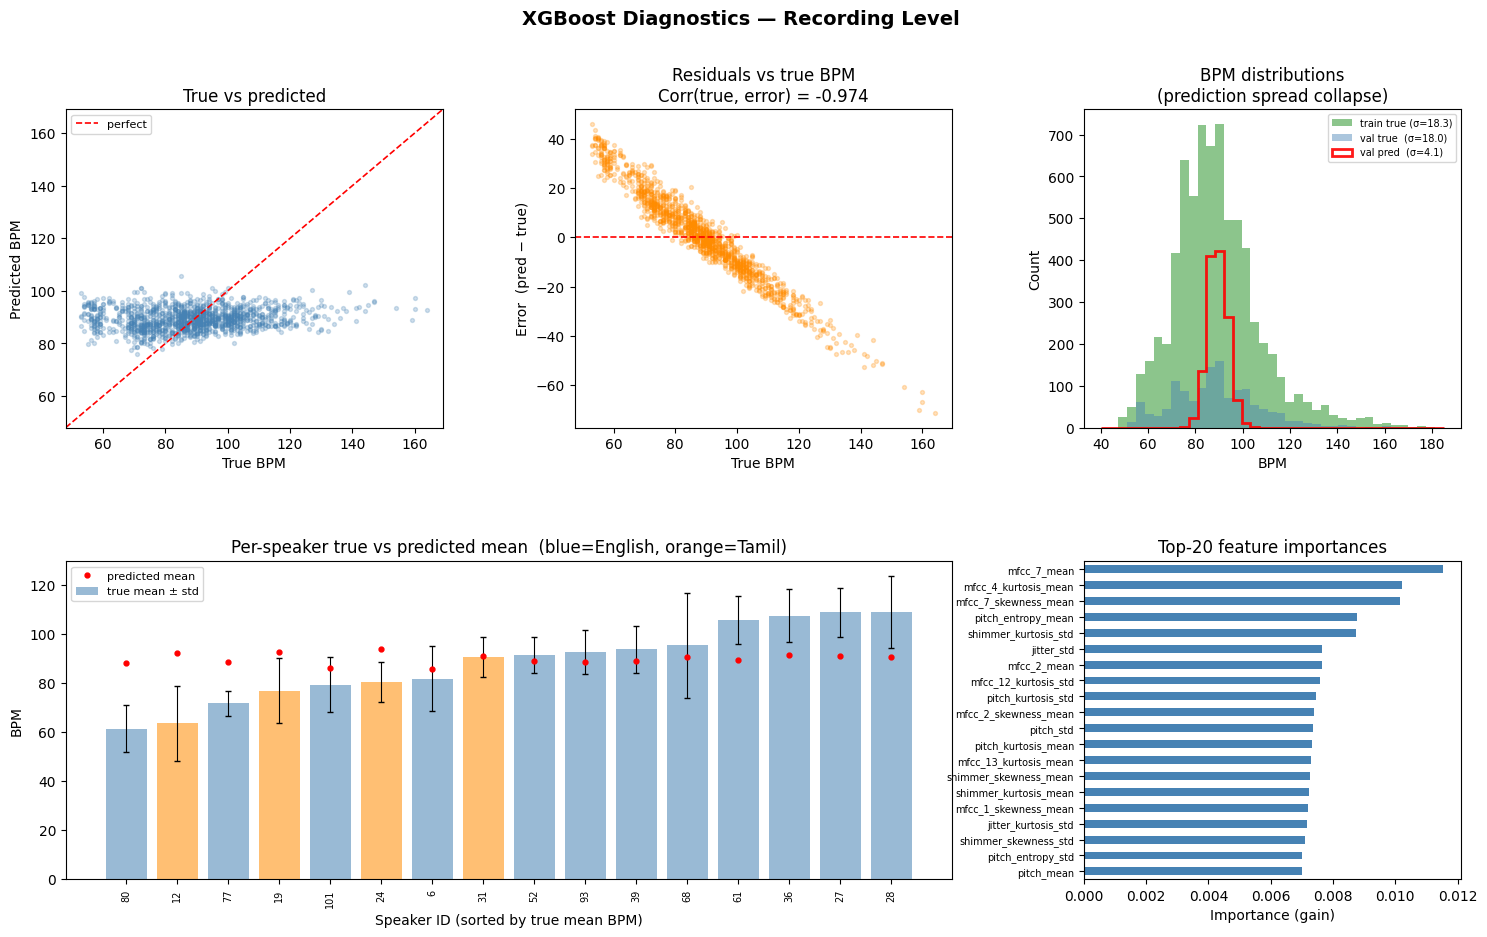

                                    RMSE        R²
Train                              8.447     0.786
Val (overall)                     17.850     0.016

std(y_true)             = 18.00 BPM
std(y_pred)             = 4.08 BPM  ← prediction spread collapse
Corr(y_true, y_pred)    = 0.154
Corr(y_true, error)     = -0.974
Saved → /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/recording_level/xgb_rec_diagnostics.png


In [20]:
# =============================================================================
# Cell 10 — Diagnostics
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Training predictions for overfitting check
y_train_pred = best_model.predict(X_train)
train_rmse = float(np.sqrt(mean_squared_error(y_train, y_train_pred)))
train_r2   = float(r2_score(y_train, y_train_pred))
val_rmse   = float(np.sqrt(mean_squared_error(y_val, y_val_pred)))
val_r2     = float(r2_score(y_val, y_val_pred))

errors = y_val_pred - y_val.values

fig = plt.figure(figsize=(18, 10))
fig.suptitle("XGBoost Diagnostics — Recording Level", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# --- (0,0) Scatter: true vs predicted ------------------------------------------
ax = fig.add_subplot(gs[0, 0])
ax.scatter(y_val, y_val_pred, alpha=0.25, s=8, color="steelblue")
lims = [min(float(y_val.min()), y_val_pred.min()) - 5,
        max(float(y_val.max()), y_val_pred.max()) + 5]
ax.plot(lims, lims, "r--", lw=1.2, label="perfect")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("True BPM"); ax.set_ylabel("Predicted BPM")
ax.set_title("True vs predicted")
ax.legend(fontsize=8)

# --- (0,1) Residuals vs true BPM -----------------------------------------------
ax = fig.add_subplot(gs[0, 1])
ax.scatter(y_val, errors, alpha=0.25, s=8, color="darkorange")
ax.axhline(0, color="red", lw=1.2, linestyle="--")
corr_err = float(np.corrcoef(y_val, errors)[0, 1])
ax.set_xlabel("True BPM"); ax.set_ylabel("Error  (pred − true)")
ax.set_title(f"Residuals vs true BPM\nCorr(true, error) = {corr_err:.3f}")

# --- (0,2) BPM distributions ---------------------------------------------------
ax = fig.add_subplot(gs[0, 2])
bins = np.linspace(40, 185, 40)
ax.hist(y_train, bins=bins, alpha=0.45, label=f"train true (σ={y_train.std():.1f})", color="green")
ax.hist(y_val,   bins=bins, alpha=0.45, label=f"val true  (σ={y_val.std():.1f})",   color="steelblue")
ax.hist(y_val_pred, bins=bins, alpha=0.9, label=f"val pred  (σ={y_val_pred.std():.1f})",
        color="red", histtype="step", linewidth=2)
ax.set_xlabel("BPM"); ax.set_ylabel("Count")
ax.set_title("BPM distributions\n(prediction spread collapse)")
ax.legend(fontsize=7)

# --- (1,0:2) Per-speaker true vs predicted mean --------------------------------
ax = fig.add_subplot(gs[1, :2])
spk_df = pd.DataFrame({
    "speaker_id": groups_val["speaker_id"].values,
    "language":   groups_val["language"].values,
    "y_true":     y_val.values,
    "y_pred":     y_val_pred,
})
spk_sum = (spk_df.groupby("speaker_id")
           .agg(true_mean=("y_true", "mean"), pred_mean=("y_pred", "mean"),
                true_std=("y_true", "std"), language=("language", "first"))
           .sort_values("true_mean"))
x = np.arange(len(spk_sum))
colors = ["steelblue" if l == "English" else "darkorange" for l in spk_sum["language"]]
ax.bar(x, spk_sum["true_mean"], yerr=spk_sum["true_std"], alpha=0.55,
       color=colors, error_kw=dict(elinewidth=0.8, capsize=2), label="true mean ± std")
ax.plot(x, spk_sum["pred_mean"], "r.", ms=7, zorder=5, label="predicted mean")
ax.set_xticks(x)
ax.set_xticklabels(spk_sum.index.astype(str), rotation=90, fontsize=7)
ax.set_xlabel("Speaker ID (sorted by true mean BPM)")
ax.set_ylabel("BPM")
ax.set_title("Per-speaker true vs predicted mean  (blue=English, orange=Tamil)")
ax.legend(fontsize=8)

# --- (1,2) Feature importance (top 20) -----------------------------------------
ax = fig.add_subplot(gs[1, 2])
fi = pd.Series(best_model.feature_importances_, index=REC_FEATURE_COLS).nlargest(20).sort_values()
fi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance (gain)")
ax.set_title("Top-20 feature importances")
ax.tick_params(axis="y", labelsize=7)

plt.savefig(OUT_DIR / "xgb_rec_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Printed summary -----------------------------------------------------------
print(f"{'':30s}  {'RMSE':>8}  {'R²':>8}")
print(f"{'Train':30s}  {train_rmse:8.3f}  {train_r2:8.3f}")
print(f"{'Val (overall)':30s}  {val_rmse:8.3f}  {val_r2:8.3f}")
print()
print(f"std(y_true)             = {float(y_val.std()):.2f} BPM")
print(f"std(y_pred)             = {y_val_pred.std():.2f} BPM  ← prediction spread collapse")
print(f"Corr(y_true, y_pred)    = {float(np.corrcoef(y_val, y_val_pred)[0,1]):.3f}")
print(f"Corr(y_true, error)     = {corr_err:.3f}")
print(f"Saved → {OUT_DIR / 'xgb_rec_diagnostics.png'}")

In [21]:
# =============================================================================
# Cell 10 — Save outputs
# =============================================================================
best_model.save_model(OUT_DIR / "xgb_rec_best.json")

with open(OUT_DIR / "xgb_rec_best_params.json", "w") as f:
    json.dump(best_params, f, indent=2, default=str)

with open(OUT_DIR / "xgb_rec_val_metrics.json", "w") as f:
    json.dump(val_metrics, f, indent=2)

val_pred_df = groups_val[["file_name", "speaker_id", "language", "gender"]].copy()
val_pred_df["y_true"] = y_val.values
val_pred_df["y_pred"] = y_val_pred
val_pred_df["error"]  = val_pred_df["y_pred"] - val_pred_df["y_true"]
val_pred_df.to_csv(OUT_DIR / "xgb_rec_val_predictions.csv", index=False)

print(f"Saved to {OUT_DIR}:")
print("  xgb_rec_best.json")
print("  xgb_rec_best_params.json")
print("  xgb_rec_val_metrics.json")
print("  xgb_rec_val_predictions.csv")

Saved to /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/recording_level:
  xgb_rec_best.json
  xgb_rec_best_params.json
  xgb_rec_val_metrics.json
  xgb_rec_val_predictions.csv
